In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [339]:
df = pd.read_csv("/content/drive/MyDrive/Crop_Project/crop.csv")
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [340]:
df.shape

(2200, 8)

In [341]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [342]:
df.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [343]:
df.duplicated().sum()

np.int64(0)

In [344]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [345]:
df['label'].value_counts()

,count
label,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


In [346]:
num_df = df.select_dtypes(include=['number'])
cv = (num_df.std() / num_df.mean()) * 100
print(cv)

N               73.028696
P               61.814462
K              105.189796
temperature     19.767725
humidity        31.146135
ph              11.962904
rainfall        53.118545
dtype: float64


In [347]:
num_df = df.select_dtypes(include=['number'])

for col in num_df.columns:
    Q1 = num_df[col].quantile(0.25)
    Q3 = num_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = num_df[(num_df[col] < lower) | (num_df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

N: 0 outliers
P: 138 outliers
K: 200 outliers
temperature: 86 outliers
humidity: 30 outliers
ph: 57 outliers
rainfall: 100 outliers


In [348]:
num_df = df.select_dtypes(include=['number'])
correlation = num_df.corr()
print(correlation)

                    N         P         K  temperature  humidity        ph  \
N            1.000000 -0.231460 -0.140512     0.026504  0.190688  0.096683   
P           -0.231460  1.000000  0.736232    -0.127541 -0.118734 -0.138019   
K           -0.140512  0.736232  1.000000    -0.160387  0.190859 -0.169503   
temperature  0.026504 -0.127541 -0.160387     1.000000  0.205320 -0.017795   
humidity     0.190688 -0.118734  0.190859     0.205320  1.000000 -0.008483   
ph           0.096683 -0.138019 -0.169503    -0.017795 -0.008483  1.000000   
rainfall     0.059020 -0.063839 -0.053461    -0.030084  0.094423 -0.109069   

             rainfall  
N            0.059020  
P           -0.063839  
K           -0.053461  
temperature -0.030084  
humidity     0.094423  
ph          -0.109069  
rainfall     1.000000  


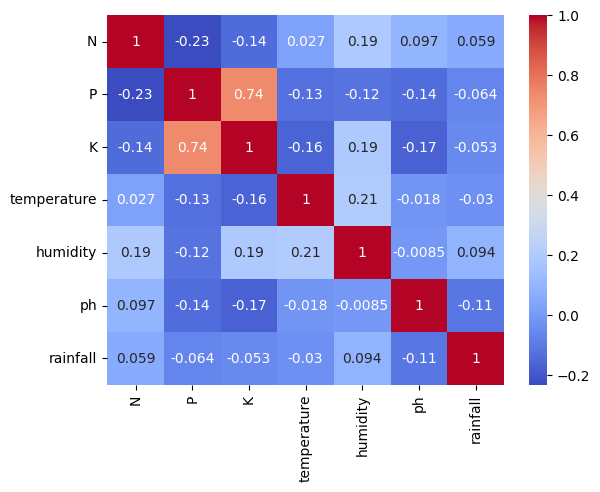

In [349]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.show()

In [350]:
df['label'].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [351]:
import seaborn as sns
import matplotlib.pyplot as plt

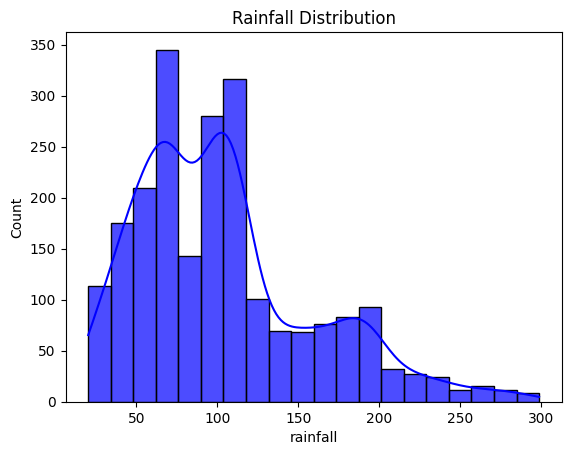

In [352]:
sns.histplot(
    df['rainfall'],
    bins=20,
    kde=True,
    color='blue',
    edgecolor='black',
    stat='count',
    alpha=0.7
)
plt.title("Rainfall Distribution")
plt.show()

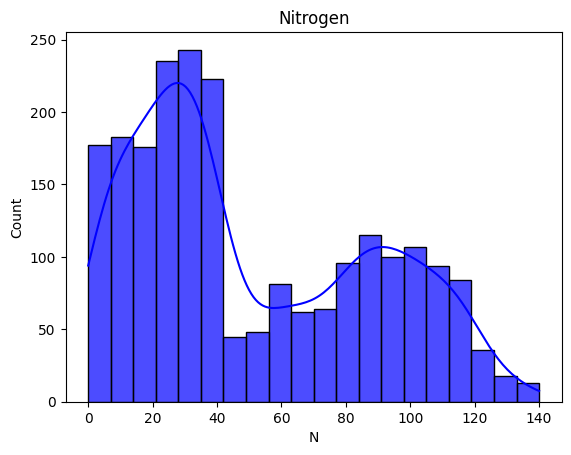

In [353]:
sns.histplot(
    df['N'],
    bins=20,
    kde=True,
    color='blue',
    edgecolor='black',
    stat='count',
    alpha=0.7
)
plt.title("Nitrogen")
plt.show()

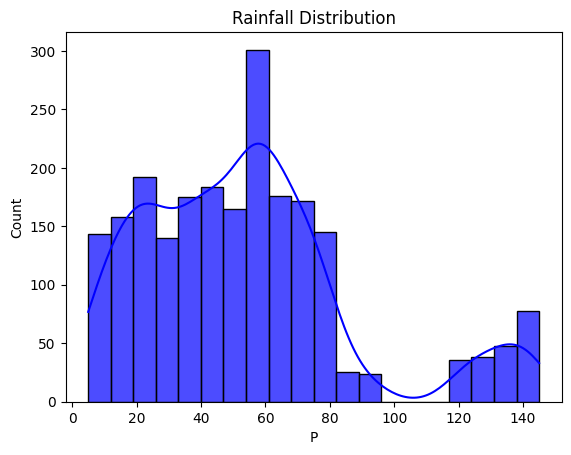

In [354]:
sns.histplot(
    df['P'],
    bins=20,
    kde=True,
    color='blue',
    edgecolor='black',
    stat='count',
    alpha=0.7
)
plt.title("Rainfall Distribution")
plt.show()

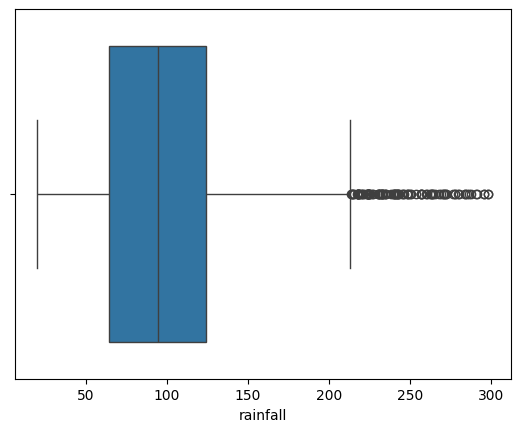

In [355]:
sns.boxplot(x=df['rainfall'])
plt.show()

In [356]:
df['rainfall'].skew()

np.float64(0.9657563536272812)

In [357]:
Q1 = df['rainfall'].quantile(0.25)
Q3 = df['rainfall'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['rainfall'] < lower) | (df['rainfall'] > upper)]
print(lower)
print(upper)
print(outliers['rainfall'])

-25.022046700000033
213.84124050000003
1       226.655537
2       263.964248
3       242.864034
4       262.717340
5       251.055000
           ...    
1867    215.196804
1881    224.831573
1886    213.901102
1892    225.632366
1894    221.225817
Name: rainfall, Length: 100, dtype: float64


In [358]:
df.label.unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [359]:
crop_dict = {
    'rice': 1,
    'maize': 2,
    'chickpea': 3,
    'kidneybeans': 4,
    'pigeonpeas': 5,
    'mothbeans': 6,
    'mungbean': 7,
    'blackgram': 8,
    'lentil': 9,
    'pomegranate': 10,
    'banana': 11,
    'mango': 12,
    'grapes': 13,
    'watermelon': 14,
    'muskmelon': 15,
    'apple': 16,
    'orange': 17,
    'papaya': 18,
    'coconut': 19,
    'cotton': 20,
    'jute': 21,
    'coffee': 22
}

In [360]:
df['label'] = df['label'].map(crop_dict)

In [361]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,1
1,85,58,41,21.770462,80.319644,7.038096,226.655537,1
2,60,55,44,23.004459,82.320763,7.840207,263.964248,1
3,74,35,40,26.491096,80.158363,6.980401,242.864034,1
4,78,42,42,20.130175,81.604873,7.628473,262.717340,1


In [362]:
X=df.drop('label',axis=1)
y=df['label']

In [363]:
print(y)


0        1
1        1
2        1
3        1
4        1
        ..
2195    22
2196    22
2197    22
2198    22
2199    22
Name: label, Length: 2200, dtype: int64


In [364]:
print(y)

0        1
1        1
2        1
3        1
4        1
        ..
2195    22
2196    22
2197    22
2198    22
2199    22
Name: label, Length: 2200, dtype: int64


In [365]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Base train:", X_train.shape)
print("Clean test:", X_test.shape)

Base train: (1760, 7)
Clean test: (440, 7)


In [366]:
import numpy as np

np.random.seed(42)

noise_std = {
    'N':           11.5,
    'P':            7.2,
    'K':            2.7,
    'temperature':  3.3,
    'humidity':     3.6,
    'ph':           0.53,
    'rainfall':    20.8
}

aug_X = [X_train]
aug_y = [y_train]

for _ in range(4):               # 4 noisy copies → 5× total
    noisy = X_train.copy()
    for col in noisy.columns:
        noisy[col] = noisy[col] + np.random.normal(0, noise_std[col], len(noisy))
    aug_X.append(noisy)
    aug_y.append(y_train)

X_train = pd.concat(aug_X, ignore_index=True)
y_train = pd.concat(aug_y, ignore_index=True)

print("Augmented train:", X_train.shape)   # (8800, 7)
print("Clean test     :", X_test.shape)    # (440, 7)  ← never touched
print("Per class (train):", y_train.value_counts().iloc[0])  # 400

Augmented train: (8800, 7)
Clean test     : (440, 7)
Per class (train): 400


In [367]:
print("Augmented train shape:", X_train.shape)
print("Test shape           :", X_test.shape)

Augmented train shape: (8800, 7)
Test shape           : (440, 7)


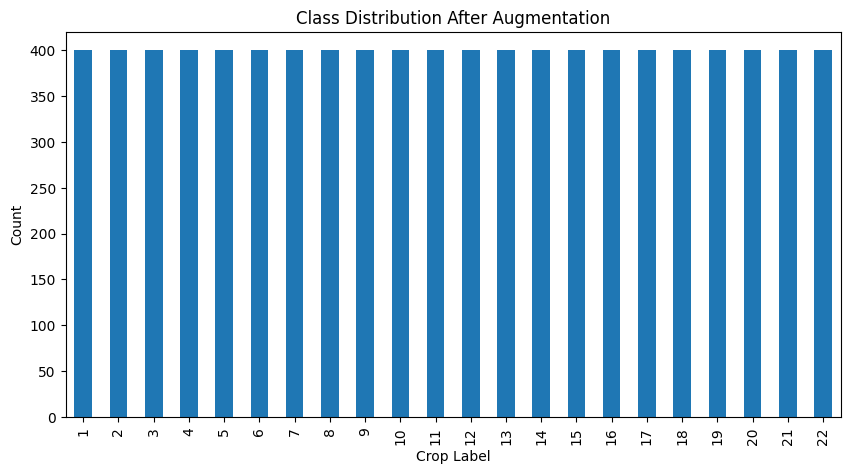

In [368]:
plt.figure(figsize=(10,5))

y_train.value_counts().sort_index().plot(kind='bar')

plt.title("Class Distribution After Augmentation")
plt.xlabel("Crop Label")
plt.ylabel("Count")

plt.show()

In [369]:
aug_df = pd.DataFrame(X_train, columns=X.columns)

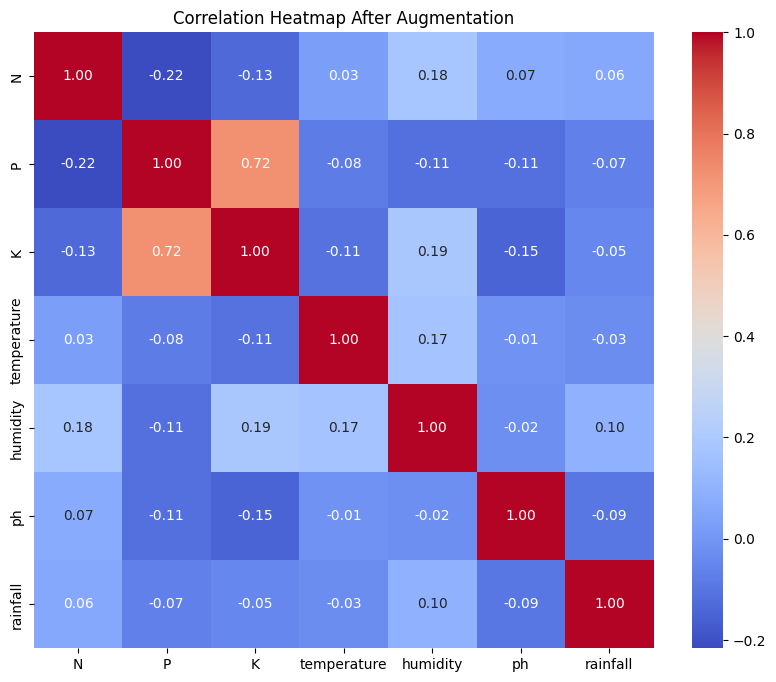

In [370]:
plt.figure(figsize=(10,8))

sns.heatmap(
    aug_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap After Augmentation")

plt.show()

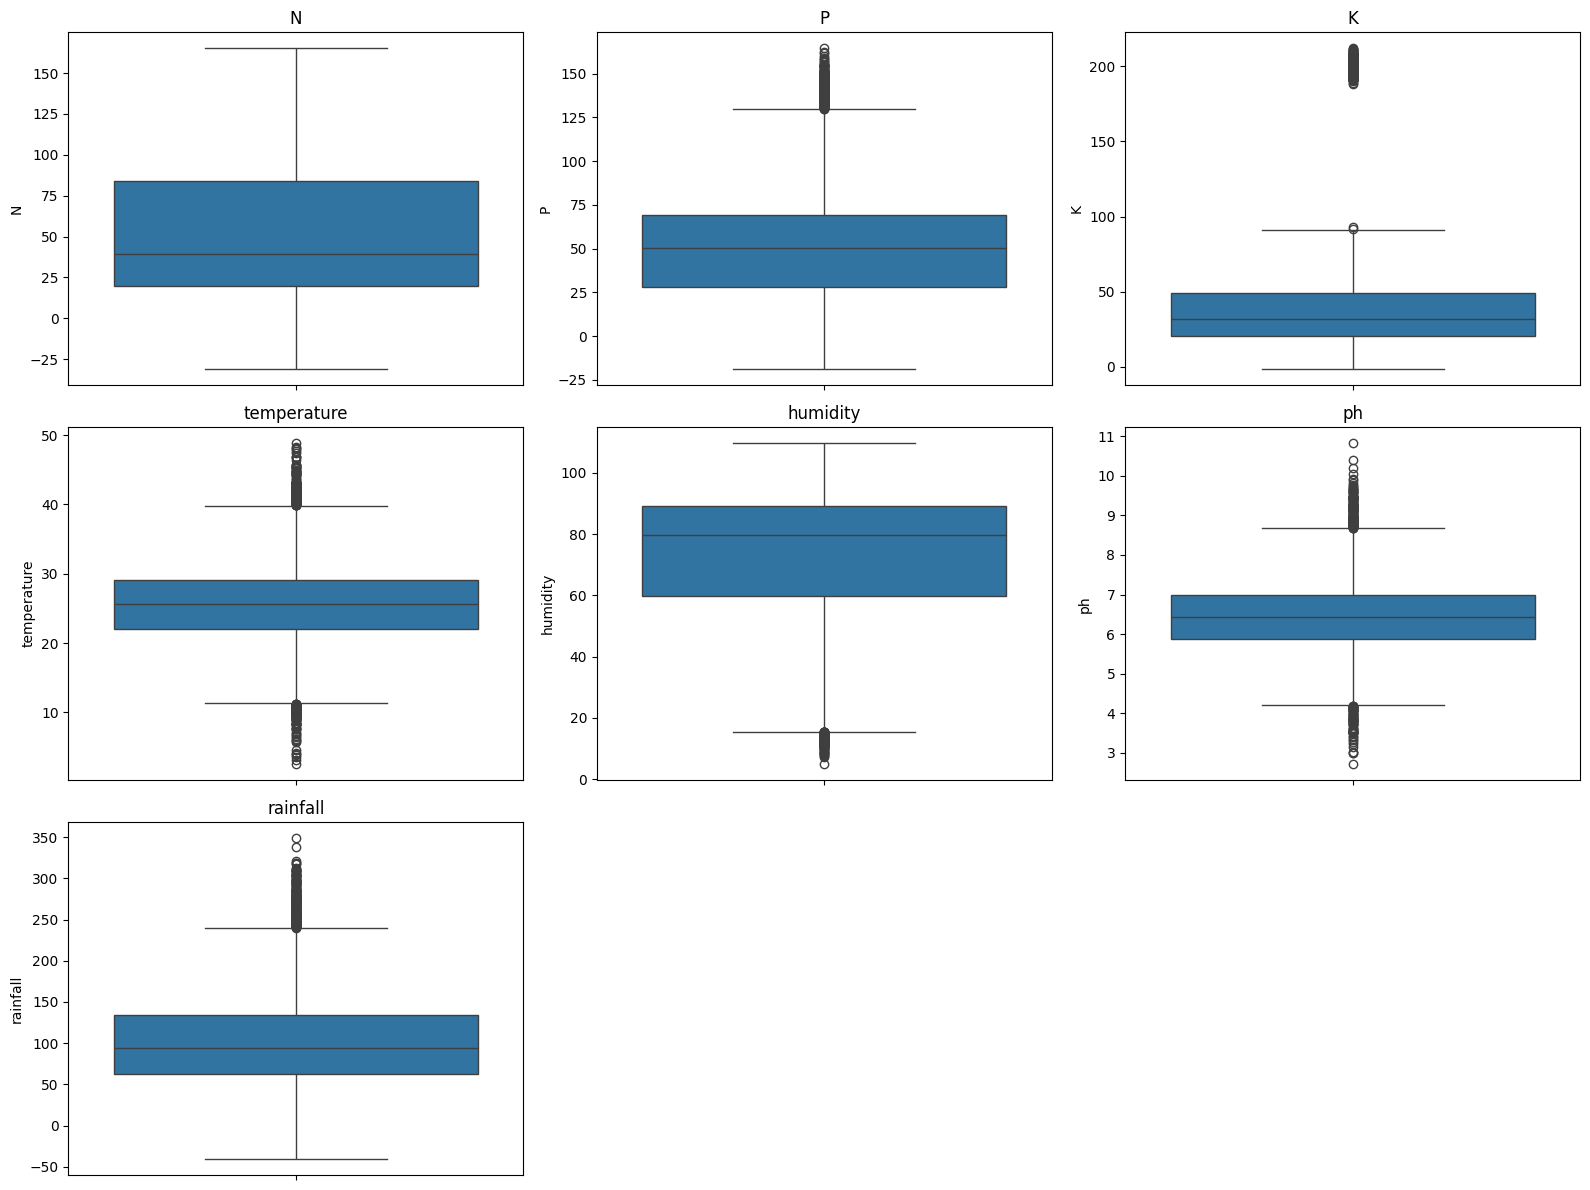

In [371]:
plt.figure(figsize=(16,12))

for i, col in enumerate(aug_df.columns):

    plt.subplot(3,3,i+1)

    sns.boxplot(y=aug_df[col])

    plt.title(col)

plt.tight_layout()
plt.show()

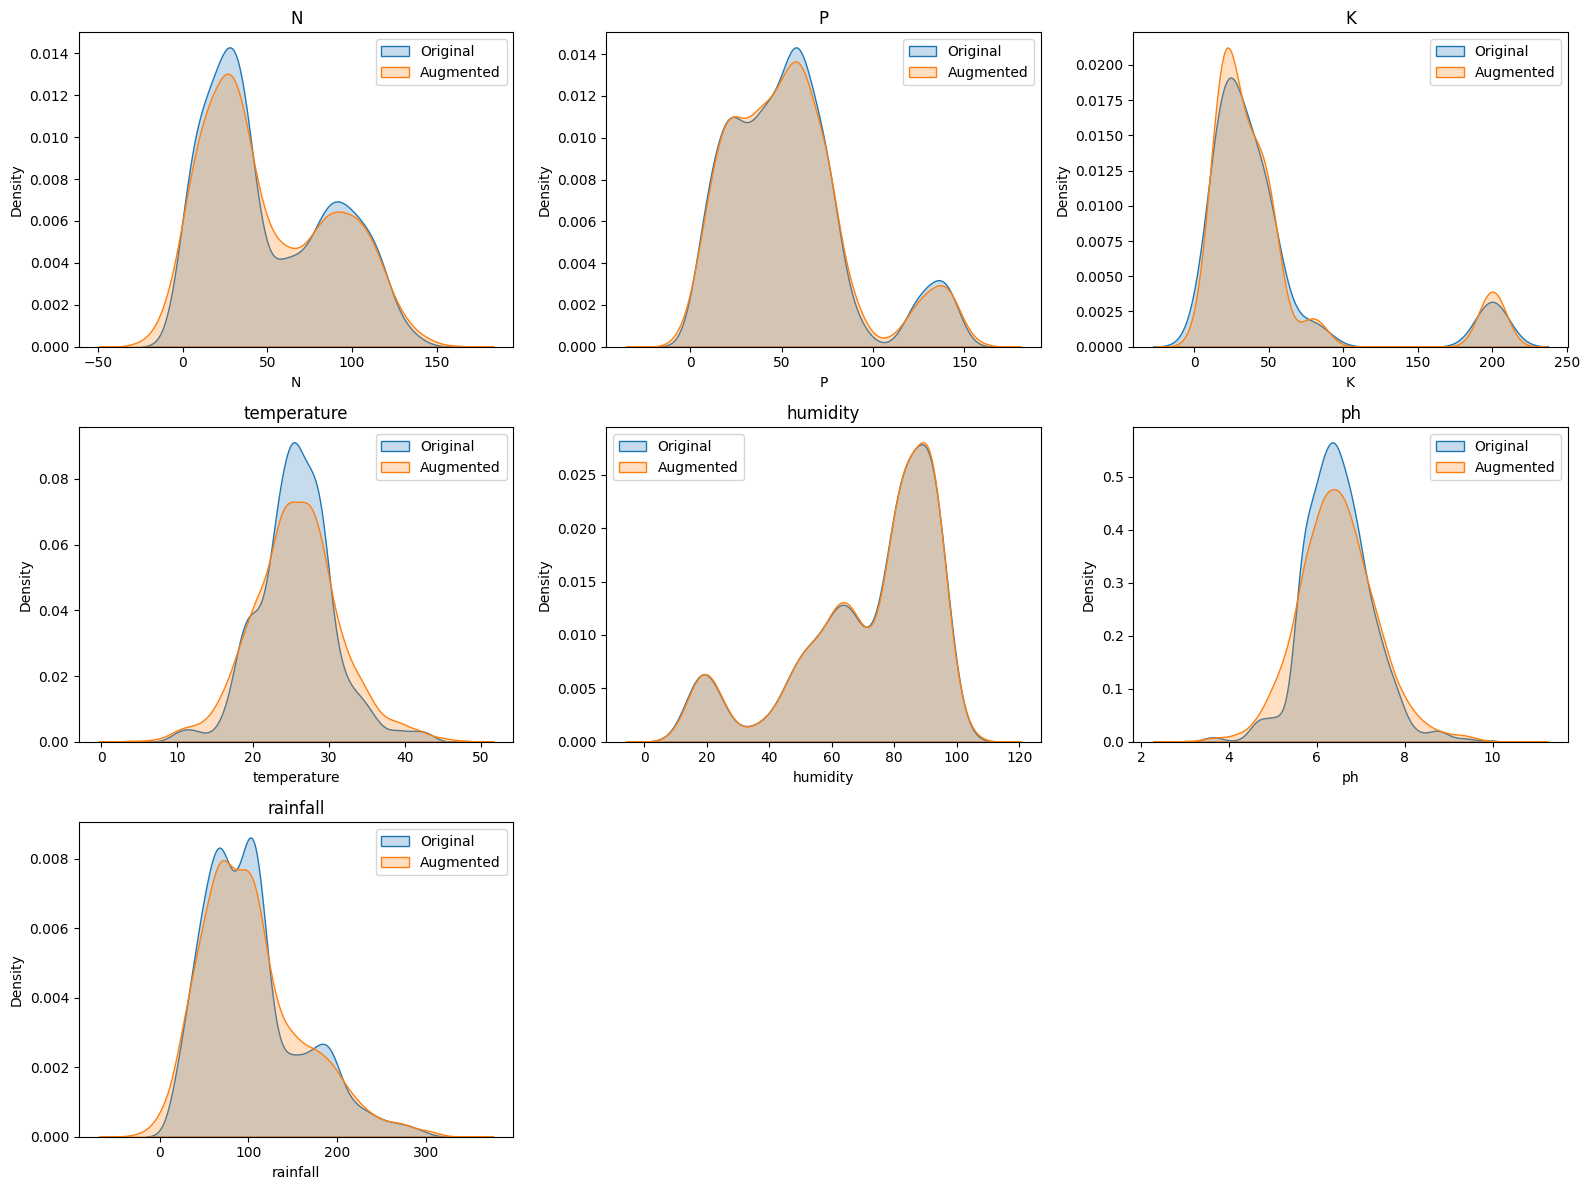

In [373]:
original_df = df.drop('label', axis=1)

plt.figure(figsize=(16,12))

for i, col in enumerate(original_df.columns):

    plt.subplot(3,3,i+1)

    sns.kdeplot(original_df[col], label='Original', fill=True)
    sns.kdeplot(aug_df[col], label='Augmented', fill=True)

    plt.title(col)
    plt.legend()

plt.tight_layout()
plt.show()

In [374]:
duplicates = aug_df.duplicated().sum()

print("Duplicate rows after augmentation:", duplicates)

Duplicate rows after augmentation: 0


In [375]:

X_train_df = pd.DataFrame(X_train, columns=X.columns)
y_train_df = pd.Series(y_train, name='label')

smote_df = pd.concat([X_train_df, y_train_df], axis=1)

print(smote_df.shape)
smote_df.head()

(8800, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,0.0,18.0,14.0,29.771494,92.007200,7.207991,114.416179,17
1,52.0,63.0,19.0,29.589490,68.321768,6.928899,67.530212,8
2,24.0,21.0,42.0,20.822107,87.228157,6.999014,109.442993,10
3,120.0,7.0,47.0,24.247825,83.036879,6.653868,54.765762,14
4,18.0,12.0,8.0,12.590940,91.816688,6.206053,119.391672,17


In [376]:
X_train.shape

(8800, 7)

In [377]:
X_test.shape

(440, 7)

In [378]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [379]:
X_train

array([[-1.32127622, -1.0531685 , -0.67277761, ...,  0.91306129,
         0.82640778,  0.19000295],
       [ 0.03789886,  0.28196362, -0.5742344 , ..., -0.14305925,
         0.51812542, -0.61905801],
       [-0.69396465, -0.96415969, -0.12093567, ...,  0.69996638,
         0.59557441,  0.10418601],
       ...,
       [-1.12773076,  0.47133952, -0.35311788, ..., -0.51242341,
         1.26977031, -0.92697768],
       [-1.39283967,  0.76933882, -0.47499179, ..., -0.52329984,
         0.60310837, -1.3888591 ],
       [-0.20792055,  0.52559077, -0.61306212, ..., -0.39779276,
         0.8184872 , -0.21894913]])

In [380]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix


In [381]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),

    'SVC': SVC(),

    'KNeighborsClassifier': KNeighborsClassifier(),

    'DecisionTreeClassifier': DecisionTreeClassifier(
        max_depth=9,

    )
}

In [382]:
results = {}
predictions = {}
train_scores = {}
test_scores = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    train_pred = model.predict(X_train)
    test_acc = accuracy_score(y_test, y_pred)
    train_acc = accuracy_score(y_train, train_pred)
    results[name] = test_acc
    predictions[name] = y_pred
    train_scores[name] = train_acc
    test_scores[name] = test_acc

In [383]:
for name in models:
    print(f"\n{name}")
    print("Train Accuracy:", train_scores[name])
    print("Test Accuracy :", test_scores[name])


LogisticRegression
Train Accuracy: 0.9246590909090909
Test Accuracy : 0.9818181818181818

SVC
Train Accuracy: 0.9407954545454545
Test Accuracy : 0.9863636363636363

KNeighborsClassifier
Train Accuracy: 0.9417045454545454
Test Accuracy : 0.9795454545454545

DecisionTreeClassifier
Train Accuracy: 0.9089772727272727
Test Accuracy : 0.9636363636363636


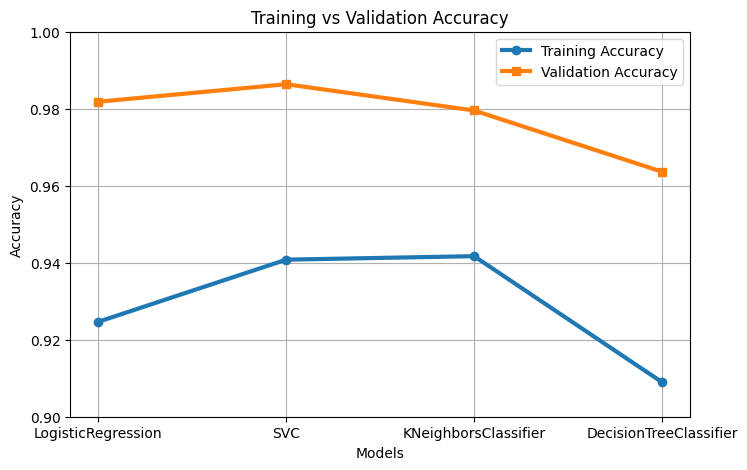

In [384]:
import matplotlib.pyplot as plt

model_names = list(train_scores.keys())

train_values = list(train_scores.values())
test_values = list(test_scores.values())

# Plot graph
plt.figure(figsize=(8,5))

plt.plot(
    model_names,
    train_values,
    marker='o',
    linewidth=3,
    label="Training Accuracy"
)

plt.plot(
    model_names,
    test_values,
    marker='s',
    linewidth=3,
    label="Validation Accuracy"
)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.ylim(0.90, 1.00)

plt.legend()
plt.grid(True)

plt.show()

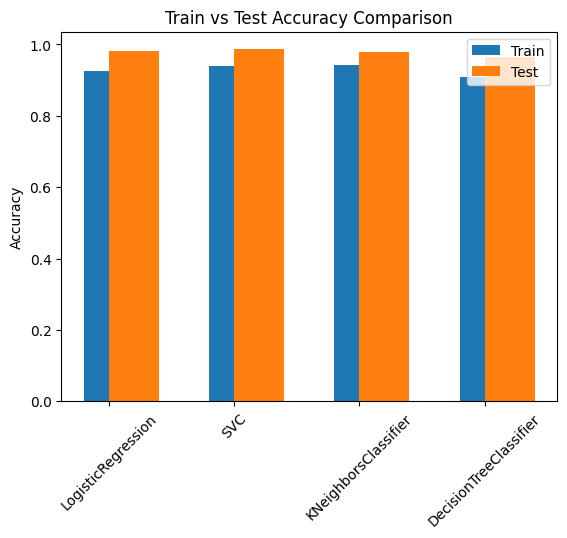

In [385]:
import matplotlib.pyplot as plt
names = list(models.keys())
train_vals = list(train_scores.values())
test_vals = list(test_scores.values())
x = range(len(names))
plt.bar(x, train_vals, width=0.4, label='Train', align='center')
plt.bar(x, test_vals, width=0.4, label='Test', align='edge')
plt.xticks(x, names, rotation=45)
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy Comparison")
plt.legend()
plt.show()

In [386]:
for name, score in results.items():
    print(name, ":", score)

LogisticRegression : 0.9818181818181818
SVC : 0.9863636363636363
KNeighborsClassifier : 0.9795454545454545
DecisionTreeClassifier : 0.9636363636363636


In [387]:
import pandas as pd
from sklearn.metrics import accuracy_score
reverse_dict = {v:k for k,v in crop_dict.items()}
for name, model in models.items():
    print(f"\n{name} Evaluation:\n")
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    correct = (preds == y_test).sum()
    wrong = (preds != y_test).sum()
    actual_labels = [reverse_dict[y] for y in y_test]
    predicted_labels = [reverse_dict[p] for p in preds]
    comparison = pd.DataFrame({
        "Actual": actual_labels,
        "Predicted": predicted_labels
    })
    print(f"Accuracy          : {acc * 100:.2f}%")
    print(f"Correct Predictions: {correct}")
    print(f"Wrong Predictions  : {wrong}")
    print("\nSample Predictions:\n")
    print(comparison.head(10))
    print("\n" + "="*60)


LogisticRegression Evaluation:

Accuracy          : 98.18%
Correct Predictions: 432
Wrong Predictions  : 8

Sample Predictions:

        Actual    Predicted
0       orange       orange
1        maize        maize
2     mungbean     mungbean
3        mango        mango
4       orange       orange
5  kidneybeans  kidneybeans
6         jute         jute
7     chickpea     chickpea
8        maize        maize
9       orange       orange


SVC Evaluation:

Accuracy          : 98.64%
Correct Predictions: 434
Wrong Predictions  : 6

Sample Predictions:

        Actual    Predicted
0       orange       orange
1        maize        maize
2     mungbean     mungbean
3        mango        mango
4       orange       orange
5  kidneybeans  kidneybeans
6         jute         jute
7     chickpea     chickpea
8        maize        maize
9       orange       orange


KNeighborsClassifier Evaluation:

Accuracy          : 97.95%
Correct Predictions: 431
Wrong Predictions  : 9

Sample Predictions:

     

In [388]:
data = [
    # 1. Rice (Needs massive rainfall, high nitrogen, high humidity)
    [90, 42, 43, 26.5, 82.0, 6.4, 250.0],

    # 2. Coffee (Needs high nitrogen, lower humidity, moderate rainfall)
    [105, 15, 30, 25.6, 58.3, 6.8, 150.0],

    # 3. Apple (Needs huge amounts of Phosphorus and Potassium, cooler temps)
    [20, 125, 200, 22.1, 92.3, 5.9, 110.0],

    # 4. Muskmelon (Needs high temperatures, low rainfall)
    [100, 17, 50, 28.8, 92.1, 6.3, 25.0],

    # 5. Cotton (Needs high nitrogen, moderate rainfall)
    [120, 40, 20, 24.0, 80.0, 6.9, 85.0],

    # 6. Lentil (Needs high phosphorus, lower humidity, low rainfall)
    [15, 65, 20, 29.9, 60.0, 7.5, 45.0],

    # 7. Banana (Needs high nitrogen & phosphorus, high humidity)
    [100, 75, 50, 27.3, 80.4, 6.0, 100.0],

    # 8. Mango (Needs high temperatures, lower humidity)
    [20, 25, 25, 30.0, 50.1, 5.5, 95.0]
]

In [389]:
data_scaled = sc.transform(data)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [390]:
reverse_dict = {v: k for k, v in crop_dict.items()}

for name, model in models.items():
    preds = model.predict(data_scaled)
    print(f"\n{name} predictions:")

    for i, p in enumerate(preds):
        print(f"Row {i+1} → {reverse_dict[p]}")


LogisticRegression predictions:
Row 1 → rice
Row 2 → coffee
Row 3 → apple
Row 4 → muskmelon
Row 5 → cotton
Row 6 → lentil
Row 7 → banana
Row 8 → mango

SVC predictions:
Row 1 → rice
Row 2 → coffee
Row 3 → apple
Row 4 → muskmelon
Row 5 → cotton
Row 6 → lentil
Row 7 → banana
Row 8 → mango

KNeighborsClassifier predictions:
Row 1 → rice
Row 2 → coffee
Row 3 → apple
Row 4 → muskmelon
Row 5 → cotton
Row 6 → mothbeans
Row 7 → banana
Row 8 → mango

DecisionTreeClassifier predictions:
Row 1 → rice
Row 2 → coffee
Row 3 → apple
Row 4 → muskmelon
Row 5 → cotton
Row 6 → lentil
Row 7 → banana
Row 8 → mango


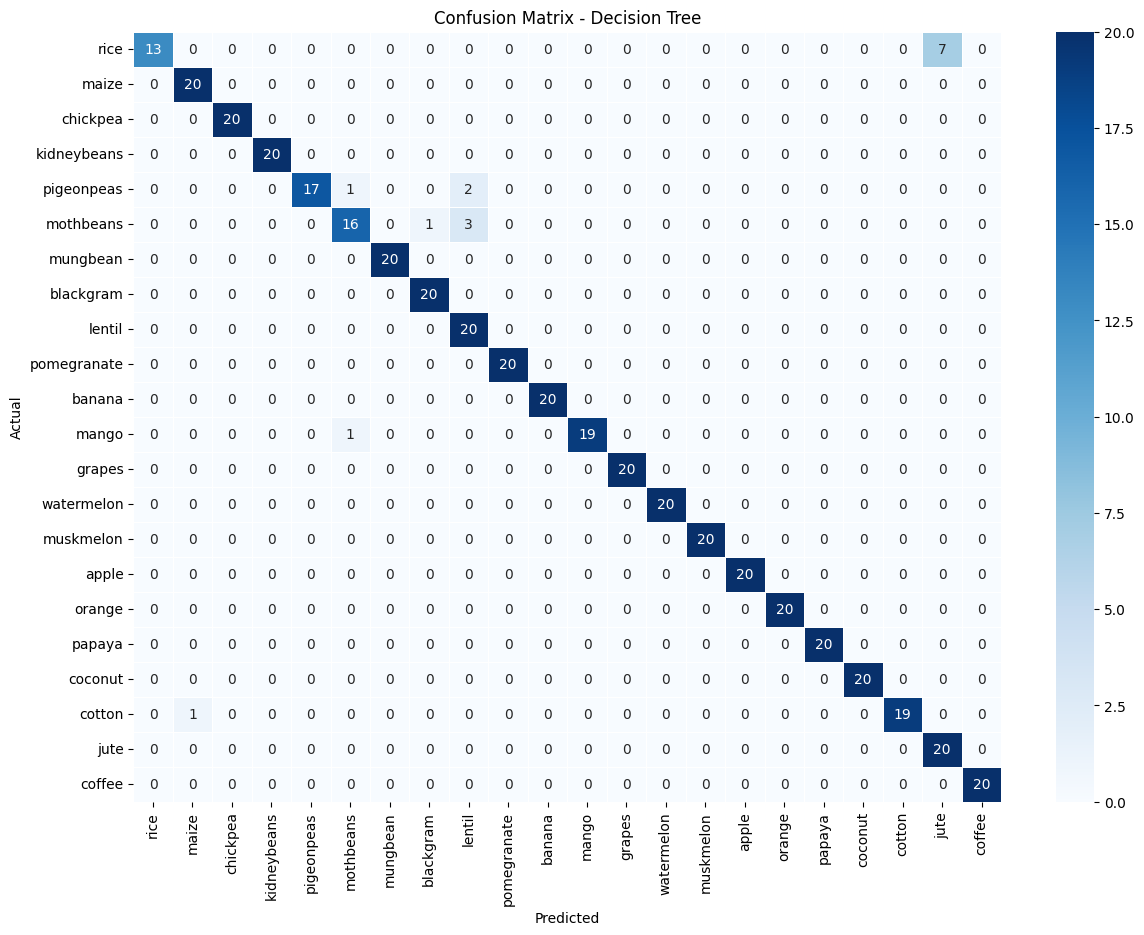

In [391]:
cm = confusion_matrix(y_test, predictions['DecisionTreeClassifier'])
label_names = list(crop_dict.keys())
plt.figure(figsize=(14,10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    xticklabels=label_names,
    yticklabels=label_names
)
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

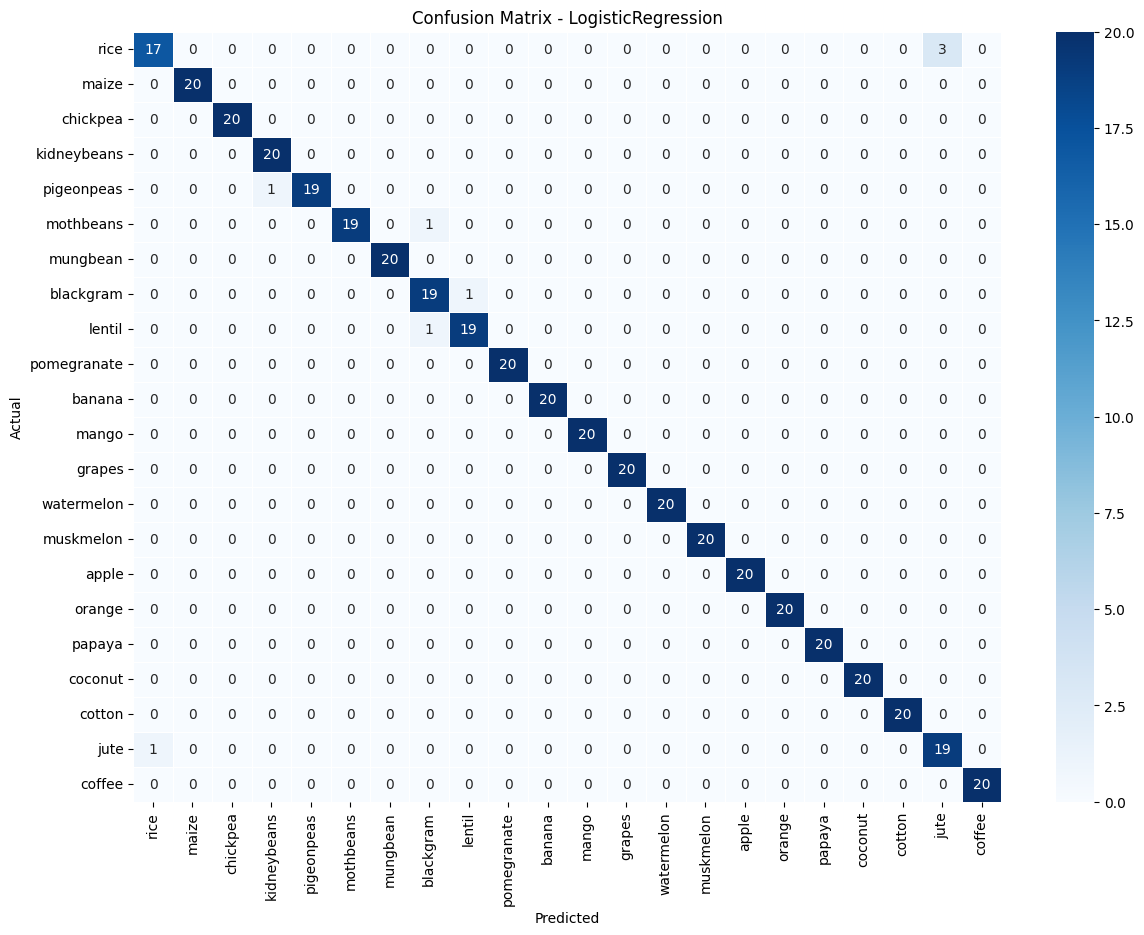

In [392]:
cm = confusion_matrix(y_test, predictions['LogisticRegression'])
label_names = list(crop_dict.keys())
plt.figure(figsize=(14,10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    xticklabels=label_names,
    yticklabels=label_names
)
plt.title("Confusion Matrix - LogisticRegression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

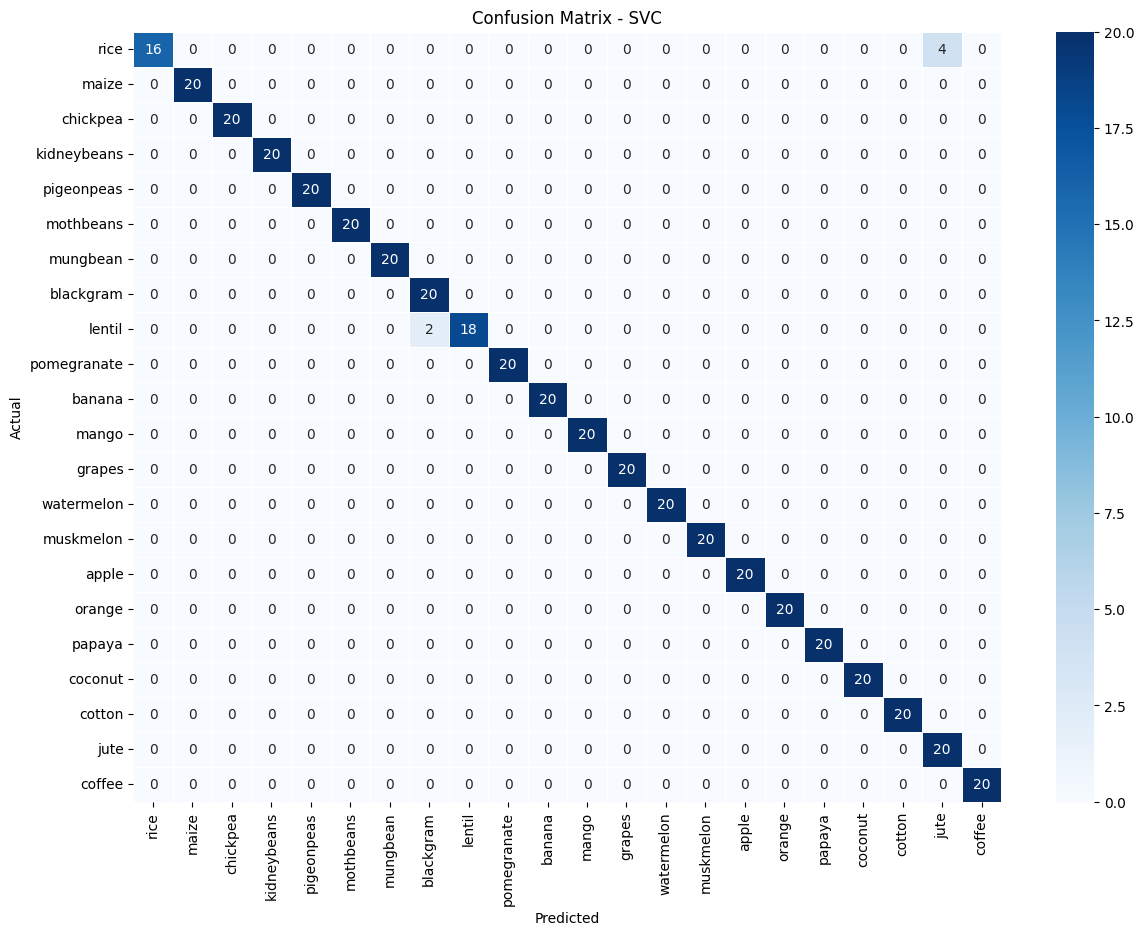

In [393]:

cm = confusion_matrix(y_test, predictions['SVC'])

label_names = list(crop_dict.keys())

plt.figure(figsize=(14,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    xticklabels=label_names,
    yticklabels=label_names
)

plt.title("Confusion Matrix - SVC")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

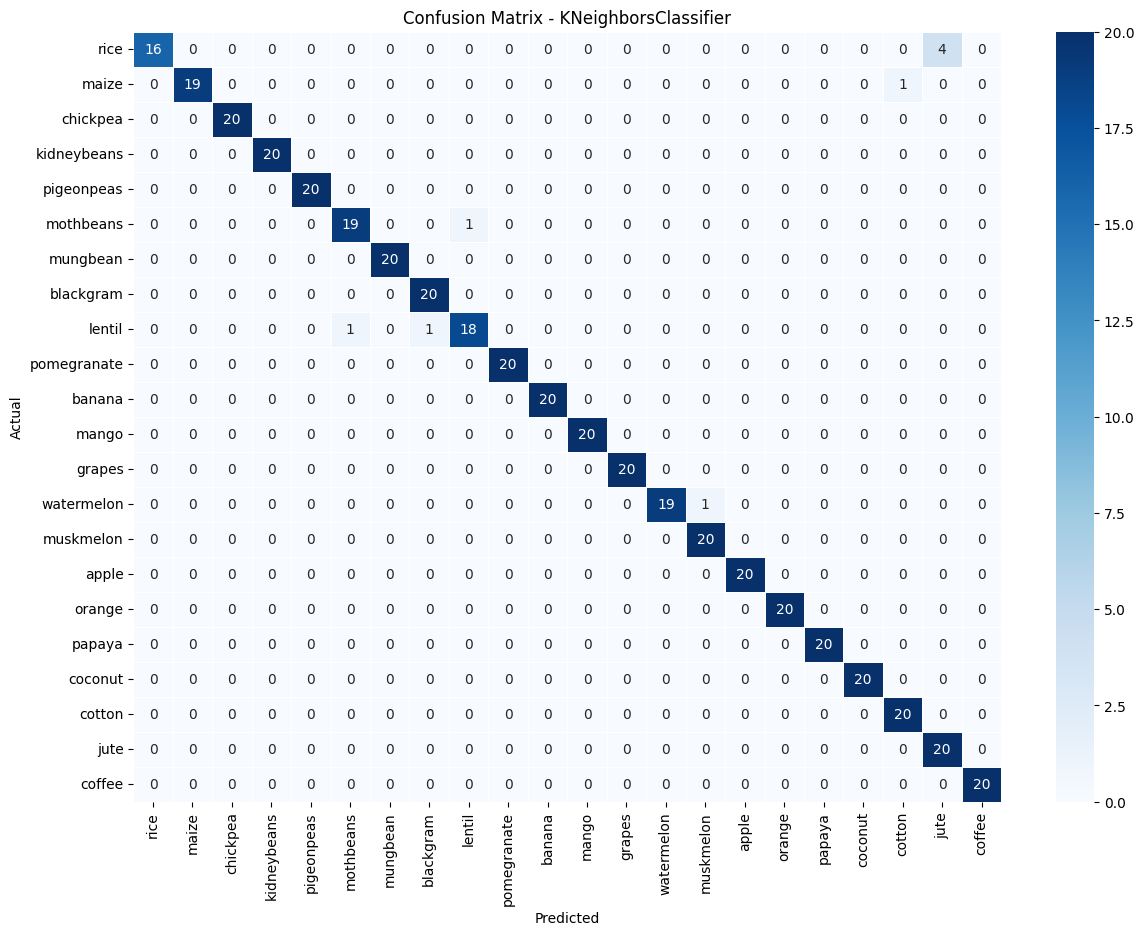

In [394]:

cm = confusion_matrix(y_test, predictions['KNeighborsClassifier'])

label_names = list(crop_dict.keys())

plt.figure(figsize=(14,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    xticklabels=label_names,
    yticklabels=label_names
)

plt.title("Confusion Matrix - KNeighborsClassifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

In [395]:
from sklearn.metrics import classification_report

for name in predictions:
    print(f"\n{name} Classification Report:\n")
    print(classification_report(y_test, predictions[name]))


LogisticRegression Classification Report:

              precision    recall  f1-score   support

           1       0.94      0.85      0.89        20
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        20
           4       0.95      1.00      0.98        20
           5       1.00      0.95      0.97        20
           6       1.00      0.95      0.97        20
           7       1.00      1.00      1.00        20
           8       0.90      0.95      0.93        20
           9       0.95      0.95      0.95        20
          10       1.00      1.00      1.00        20
          11       1.00      1.00      1.00        20
          12       1.00      1.00      1.00        20
          13       1.00      1.00      1.00        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00      1.00      1.00        20
          17       1.00      1.00    

In [396]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier


In [397]:
estimators = [
    ('svc', SVC(probability=True)),
    ('knn', KNeighborsClassifier()),
    ('dt', DecisionTreeClassifier(max_depth=8)),
    ('lr', LogisticRegression(max_iter=1000))
]

In [398]:
meta_model = RandomForestClassifier(n_estimators=100)

In [399]:
stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_model
)

In [400]:
stack_model.fit(X_train, y_train)

StackingClassifier(estimators=[('svc', SVC(probability=True)),
                               ('knn', KNeighborsClassifier()),
                               ('dt', DecisionTreeClassifier(max_depth=8)),
                               ('lr', LogisticRegression(max_iter=1000))],
                   final_estimator=RandomForestClassifier())

In [401]:
y_pred_stack = stack_model.predict(X_test)

stack_acc = accuracy_score(y_test, y_pred_stack)

print("Stacking Accuracy:", stack_acc)

Stacking Accuracy: 0.9840909090909091


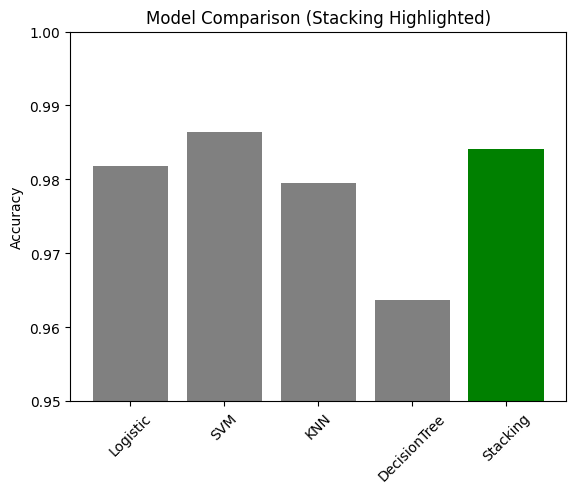

In [402]:
names = ['Logistic', 'SVM', 'KNN', 'DecisionTree', 'Stacking']
values = [
    results['LogisticRegression'],
    results['SVC'],
    results['KNeighborsClassifier'],
    results['DecisionTreeClassifier'],
    stack_acc
]

import matplotlib.pyplot as plt

colors = ['gray', 'gray', 'gray', 'gray', 'green']

plt.bar(names, values, color=colors)

plt.ylim(0.95, 1.0)
plt.title("Model Comparison (Stacking Highlighted)")
plt.ylabel("Accuracy")

plt.xticks(rotation=45)
plt.show()

In [403]:
row = df.loc[y_test.index[0]]

sample = [[row[col] for col in X.columns]]

sample_scaled = sc.transform(sample)

pred = stack_model.predict(sample_scaled)

reverse_dict = {v:k for k,v in crop_dict.items()}

print("Actual:", reverse_dict[row['label']])
print("Predicted:", reverse_dict[pred[0]])

Actual: orange
Predicted: orange


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [404]:
N = float(input("Enter Nitrogen: "))
P = float(input("Enter Phosphorus: "))
K = float(input("Enter Potassium: "))
temp = float(input("Enter Temperature: "))
humidity = float(input("Enter Humidity: "))
ph = float(input("Enter pH: "))
rainfall = float(input("Enter Rainfall: "))
sample_dict = {
    'N': N,
    'P': P,
    'K': K,
    'temperature': temp,
    'humidity': humidity,
    'ph': ph,
    'rainfall': rainfall
}

sample = [[sample_dict[col] for col in X.columns]]
sample_scaled = sc.transform(sample)

pred = stack_model.predict(sample_scaled)

reverse_dict = {v:k for k,v in crop_dict.items()}

print("Recommended Crop:", reverse_dict[pred[0]])

Enter Nitrogen: 18
Enter Phosphorus: 74
Enter Potassium: 25
Enter Temperature: 28.7
Enter Humidity: 58.3
Enter pH: 7.8
Enter Rainfall: 65.4
Recommended Crop: lentil


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [407]:
import os

save_path = "/content/drive/MyDrive/crop_project"
os.makedirs(save_path, exist_ok=True)

print("Folder ready:", save_path)

Folder ready: /content/drive/MyDrive/crop_project


In [408]:
import joblib

# Level-0 models
joblib.dump(models['LogisticRegression'], f"{save_path}/lr_model.pkl")
joblib.dump(models['SVC'], f"{save_path}/svc_model.pkl")
joblib.dump(models['KNeighborsClassifier'], f"{save_path}/knn_model.pkl")
joblib.dump(models['DecisionTreeClassifier'], f"{save_path}/dt_model.pkl")

# Level-1 model (stacking)
joblib.dump(stack_model, f"{save_path}/stack_model.pkl")

# Scaler + mapping
joblib.dump(sc, f"{save_path}/scaler.pkl")
joblib.dump(crop_dict, f"{save_path}/mapping.pkl")

print("All models saved permanently ")

All models saved permanently 


In [409]:
print(os.listdir(save_path))

['scaler.pkl', 'svc_model.pkl', 'lr_model.pkl', 'dt_model.pkl', 'knn_model.pkl', 'mapping.pkl', 'stack_model.pkl']


In [410]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [411]:
metrics = {}

for name, model in models.items():
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    metrics[name] = [acc, prec, rec, f1]

In [412]:
y_pred_stack = stack_model.predict(X_test)

metrics["Stacking"] = [
    accuracy_score(y_test, y_pred_stack),
    precision_score(y_test, y_pred_stack, average='weighted'),
    recall_score(y_test, y_pred_stack, average='weighted'),
    f1_score(y_test, y_pred_stack, average='weighted')
]

In [413]:
import pandas as pd

df_results = pd.DataFrame(metrics,
                          index=["Accuracy", "Precision", "Recall", "F1"]).T

df_results["Accuracy"] = df_results["Accuracy"] * 100

df_results = df_results.round(2)

print(df_results)

                        Accuracy  Precision  Recall    F1
LogisticRegression         98.18       0.98    0.98  0.98
SVC                        98.64       0.99    0.99  0.99
KNeighborsClassifier       97.95       0.98    0.98  0.98
DecisionTreeClassifier     96.36       0.97    0.96  0.96
Stacking                   98.41       0.98    0.98  0.98


In [414]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_stack)
print(cm)

[[17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  3  0]
 [ 0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 19  1  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  1 19  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0

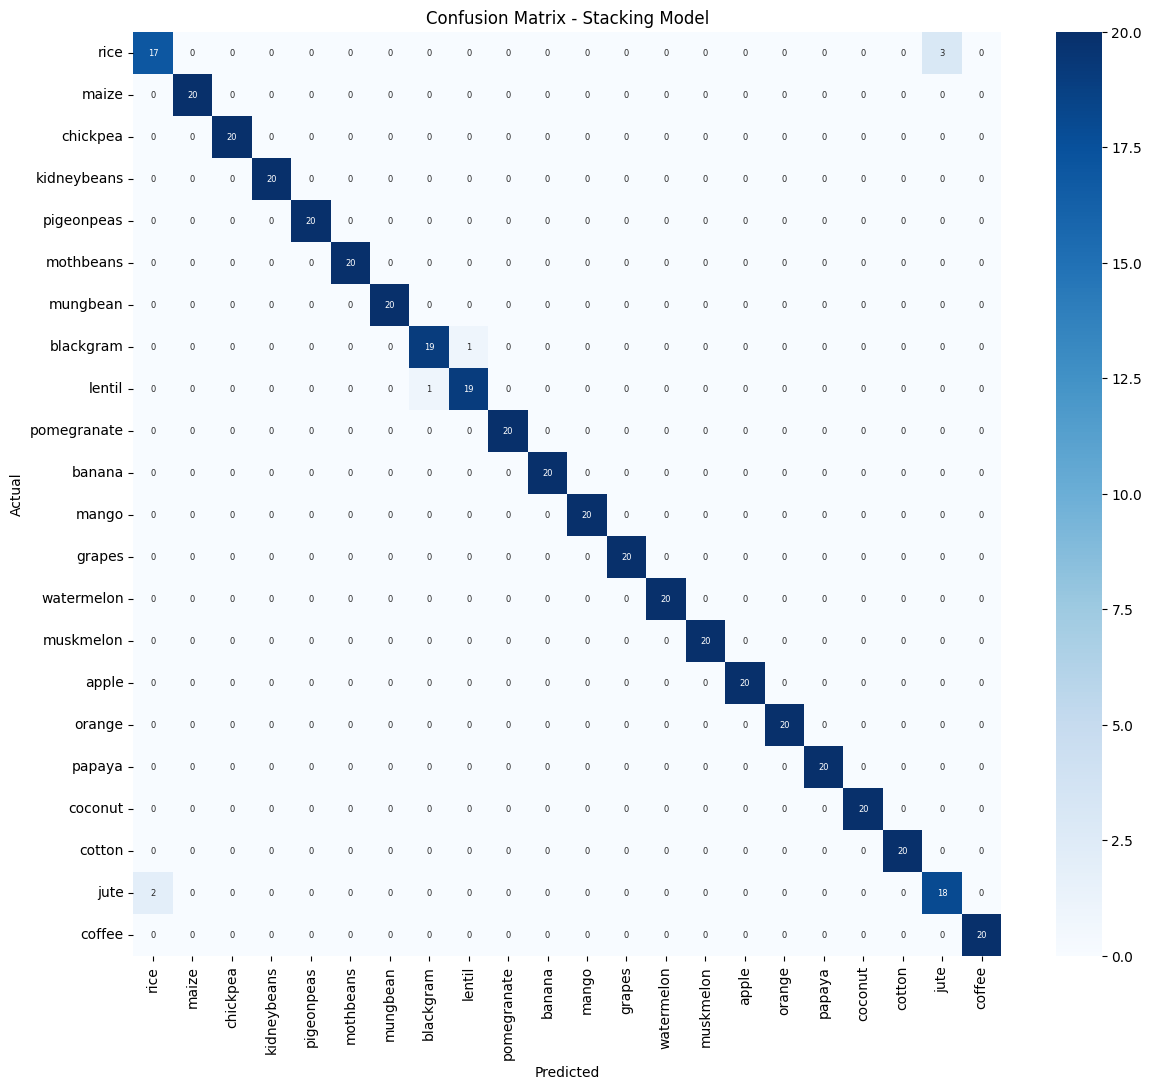

In [415]:
plt.figure(figsize=(14,12))
label_names = list(crop_dict.keys())

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    annot_kws={"size":6},
    xticklabels=label_names,
    yticklabels=label_names
)

plt.title("Confusion Matrix - Stacking Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

In [418]:
from google.colab import files

files.download(f"{save_path}/stack_model.pkl")
files.download(f"{save_path}/scaler.pkl")
files.download(f"{save_path}/mapping.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>